In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
data = pd.read_csv("data/student-mat.csv", sep=";")

data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
print("Dataset Shape:")
print(data.shape)

print("\nDataset Information:")
data.info()

Dataset Shape:
(395, 33)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 

In [8]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [9]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [10]:
features = [
    "studytime",
    "absences",
    "failures",
    "G1",
    "G2",
    "age",
    "Medu",
    "Fedu",
    "goout",
    "health"
]

X = data[features]
y = data["G3"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   studytime  absences  failures  G1  G2  age  Medu  Fedu  goout  health
0          2         6         0   5   6   18     4     4      4       3
1          2         4         0   5   5   17     1     1      3       3
2          2        10         3   7   8   15     1     1      2       3
3          3         2         0  15  14   15     4     2      2       5
4          2         4         0   6  10   16     3     3      2       5

Target:
0     6
1     6
2    10
3    15
4    10
Name: G3, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 316
Testing samples: 79


In [22]:
depths = [1, 3, 7, 15]

results = []
for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    # Training and testing MSE
    train_mse = mean_squared_error(
        y_train,
        train_prediction
    )

    test_mse = mean_squared_error(
        y_test,
        test_prediction
    )

    # Training and testing R²
    train_r2 = r2_score(
        y_train,
        train_prediction
    )

    test_r2 = r2_score(
        y_test,
        test_prediction
    )

    # Store results
    results.append({
        "Depth": depth,
        "Training MSE": train_mse,
        "Testing MSE": test_mse,
        "Training R2": train_r2,
        "Testing R2": test_r2
    })

In [23]:
results_df = pd.DataFrame(results)

results_df
results_df["MSE Gap"] = (
    results_df["Testing MSE"] -
    results_df["Training MSE"]
)

results_df

,Depth,Training MSE,Testing MSE,Training R2,Testing R2,MSE Gap
0,1,10.157792,8.096321,0.516400,0.605155,-2.061471
1,3,2.547408,4.703328,0.878721,0.770626,2.155920
2,7,0.169394,6.052339,0.991935,0.704837,5.882944
3,15,0.000000,6.177215,1.000000,0.698747,6.177215


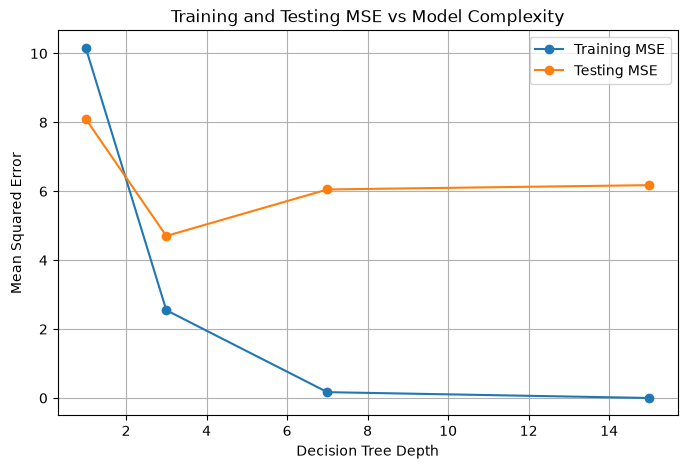

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Depth"],
    results_df["Training MSE"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    results_df["Depth"],
    results_df["Testing MSE"],
    marker="o",
    label="Testing MSE"
)

plt.xlabel("Decision Tree Depth")
plt.ylabel("Mean Squared Error")

plt.title(
    "Training and Testing MSE vs Model Complexity"
)

plt.legend()
plt.grid(True)

plt.show()

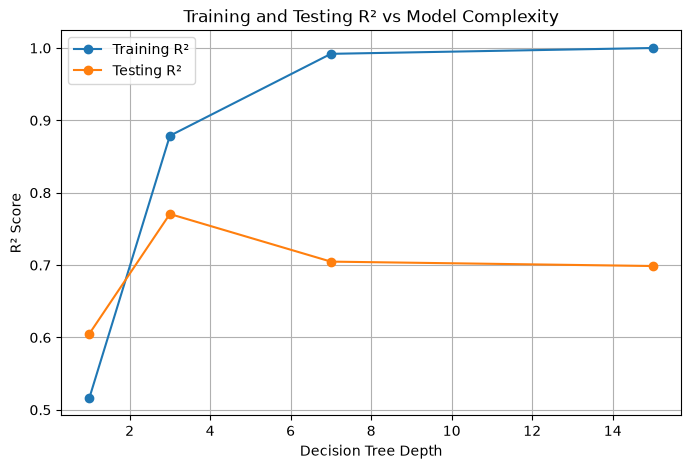

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Depth"],
    results_df["Training R2"],
    marker="o",
    label="Training R²"
)

plt.plot(
    results_df["Depth"],
    results_df["Testing R2"],
    marker="o",
    label="Testing R²"
)

plt.xlabel("Decision Tree Depth")
plt.ylabel("R² Score")

plt.title(
    "Training and Testing R² vs Model Complexity"
)

plt.legend()
plt.grid(True)

plt.show()

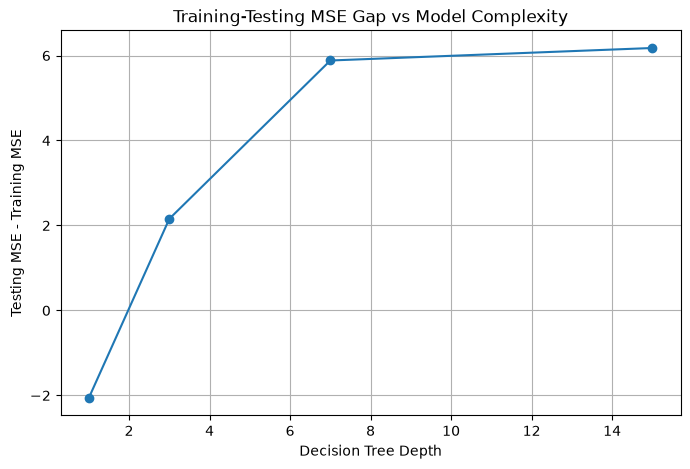

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Depth"],
    results_df["MSE Gap"],
    marker="o"
)

plt.xlabel("Decision Tree Depth")
plt.ylabel("Testing MSE - Training MSE")

plt.title(
    "Training-Testing MSE Gap vs Model Complexity"
)

plt.grid(True)

plt.show()

In [27]:
lowest_test_error = results_df.loc[
    results_df["Testing MSE"].idxmin()
]

print("Depth with lowest Testing MSE:")
print(lowest_test_error["Depth"])

print("\nTesting MSE:")
print(lowest_test_error["Testing MSE"])

Depth with lowest Testing MSE:
3.0

Testing MSE:
4.703328168928239


In [28]:
largest_gap = results_df.loc[
    results_df["MSE Gap"].idxmax()
]

print("Depth with largest Training-Testing MSE gap:")
print(largest_gap["Depth"])

print("\nMSE Gap:")
print(largest_gap["MSE Gap"])

Depth with largest Training-Testing MSE gap:
15.0

MSE Gap:
6.177215189873418


In [29]:
results_df.round(3)

,Depth,Training MSE,Testing MSE,Training R2,Testing R2,MSE Gap
0,1,10.158,8.096,0.516,0.605,-2.061
1,3,2.547,4.703,0.879,0.771,2.156
2,7,0.169,6.052,0.992,0.705,5.883
3,15,0.000,6.177,1.000,0.699,6.177
